# **Capstone project: Providing data-driven suggestions for HR**

## Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

## Data Dictionary

**Note:** For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## **Step 1. Imports**

*   Import packages
*   Load dataset



### 1.1 Import packages

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import warnings
warnings.filterwarnings('ignore')

### 1.2 Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




## **Step 2. Data Exploration**

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### __init.

In [3]:
def check_dataframe_boxplot(df, show_head=True, plot_boxplots=True):
    """
    Perform a comprehensive DataFrame inspection:
    1. Metadata (df.info())
    2. Duplicate check (df.duplicated().sum())
    3. Missing values check (df.isna().sum())
    4. Descriptive statistics (df.describe().T) +
       outlier statistics based on IQR +
       missing value statistics
    5. Preview data (df.head())

    Parameters:
    ----------
    df : pandas.DataFrame
        DataFrame to inspect.
    show_head : bool, default=True
        Display the first 5 rows.
    plot_boxplots : bool, default=True
        Draw box plots for each numeric column in the DataFrame.
    """

    print("=" * 65)
    print("1. DATASET METADATA")
    print("=" * 65)
    df.info()
    print("\n")

    print("=" * 65)
    print("2. DUPLICATE DATA CHECK")
    print("=" * 65)
    dup_count = df.duplicated().sum()
    dup_ratio = (dup_count / len(df)) * 100 if len(df) > 0 else 0
    print(f"- Number of duplicate rows: {dup_count:,} ({dup_ratio:.2f}%)")
    print("\n")

    print("=" * 65)
    print("3. MISSING VALUES CHECK")
    print("=" * 65)
    null_count = df.isna().sum()
    null_ratio = (df.isna().sum() / len(df)) * 100 if len(df) > 0 else 0

    missing_df = pd.DataFrame(
        {
            "Data Type": df.dtypes,
            "Missing Count": null_count,
            "Missing Ratio (%)": null_ratio.round(2),
        }
    )

    missing_only = missing_df[missing_df["Missing Count"] > 0]

    if not missing_only.empty:
        print(missing_only.to_string())
    else:
        print("-> No missing values found in any column.")
    print("\n")

    print("=" * 65)
    print("4. DESCRIPTIVE STATISTICS & OUTLIER DETECTION (BOX PLOT)")
    print("=" * 65)

    num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
    num_cols = [
        col for col in num_cols
        if not re.search(r"(^id$|.*id$)", col.lower())
    ]

    n_cols = len(num_cols)

    if n_cols > 0:
        # Basic descriptive statistics
        desc = df[num_cols].describe().T

        # Calculate outlier counts using the IQR rule
        # (Q1 - 1.5*IQR to Q3 + 1.5*IQR)
        outlier_counts = {}

        for col in num_cols:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1

            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            outlier_counts[col] = (
                ((df[col] < lower) | (df[col] > upper)).sum()
            )

        desc["outliers_iqr"] = pd.Series(outlier_counts)
        desc["outliers_iqr_ratio"] = (
            desc["outliers_iqr"] / len(df)
        ) * 100

        desc["missing"] = df[num_cols].isna().sum()
        desc["missing_ratio"] = (
            df[num_cols].isna().mean() * 100
        ).round(2)

        print(desc.round(2).to_string())
        print("\n")

        # Draw box plots for numeric columns
        if plot_boxplots:
            # Automatically determine plot layout
            # (maximum 3 columns per row)
            ncols_plot = min(n_cols, 3)
            nrows_plot = (n_cols + ncols_plot - 1) // ncols_plot

            fig, axes = plt.subplots(
                nrows=nrows_plot,
                ncols=ncols_plot,
                figsize=(5 * ncols_plot, 4 * nrows_plot),
            )

            axes = np.array(axes).reshape(-1)

            sns.set_style("dark")

            for idx, col in enumerate(num_cols):
                sns.boxplot(
                    y=df[col],
                    ax=axes[idx],
                    color="#3182bd"
                )

                axes[idx].set_title(
                    f"Boxplot: {col}",
                    fontsize=11,
                    fontweight="bold",
                )

                axes[idx].set_ylabel("")
                axes[idx].grid(
                    True,
                    linestyle="--",
                    alpha=0.5,
                )

            # Remove unused subplots
            for idx in range(n_cols, len(axes)):
                fig.delaxes(axes[idx])

            plt.tight_layout()
            plt.show()

    else:
        print("-> No numeric columns found in the DataFrame.")

    print("\n")

    # Preview first 5 rows
    if show_head:
        print("=" * 65)
        print("5. PREVIEW OF THE FIRST 5 ROWS")
        print("=" * 65)
        print(df.head().to_string())
        print("\n")

### 2.1 Get basic information about the data

1. DATASET METADATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


2. DUPLICATE DATA CHECK
- Number of duplicate rows: 3,008 (20.05%)


3. MISSING VALUES CHECK
-> No missing values found in any column.


4. DESCRIPTIVE STATISTICS & OUTLIER DETECTION 

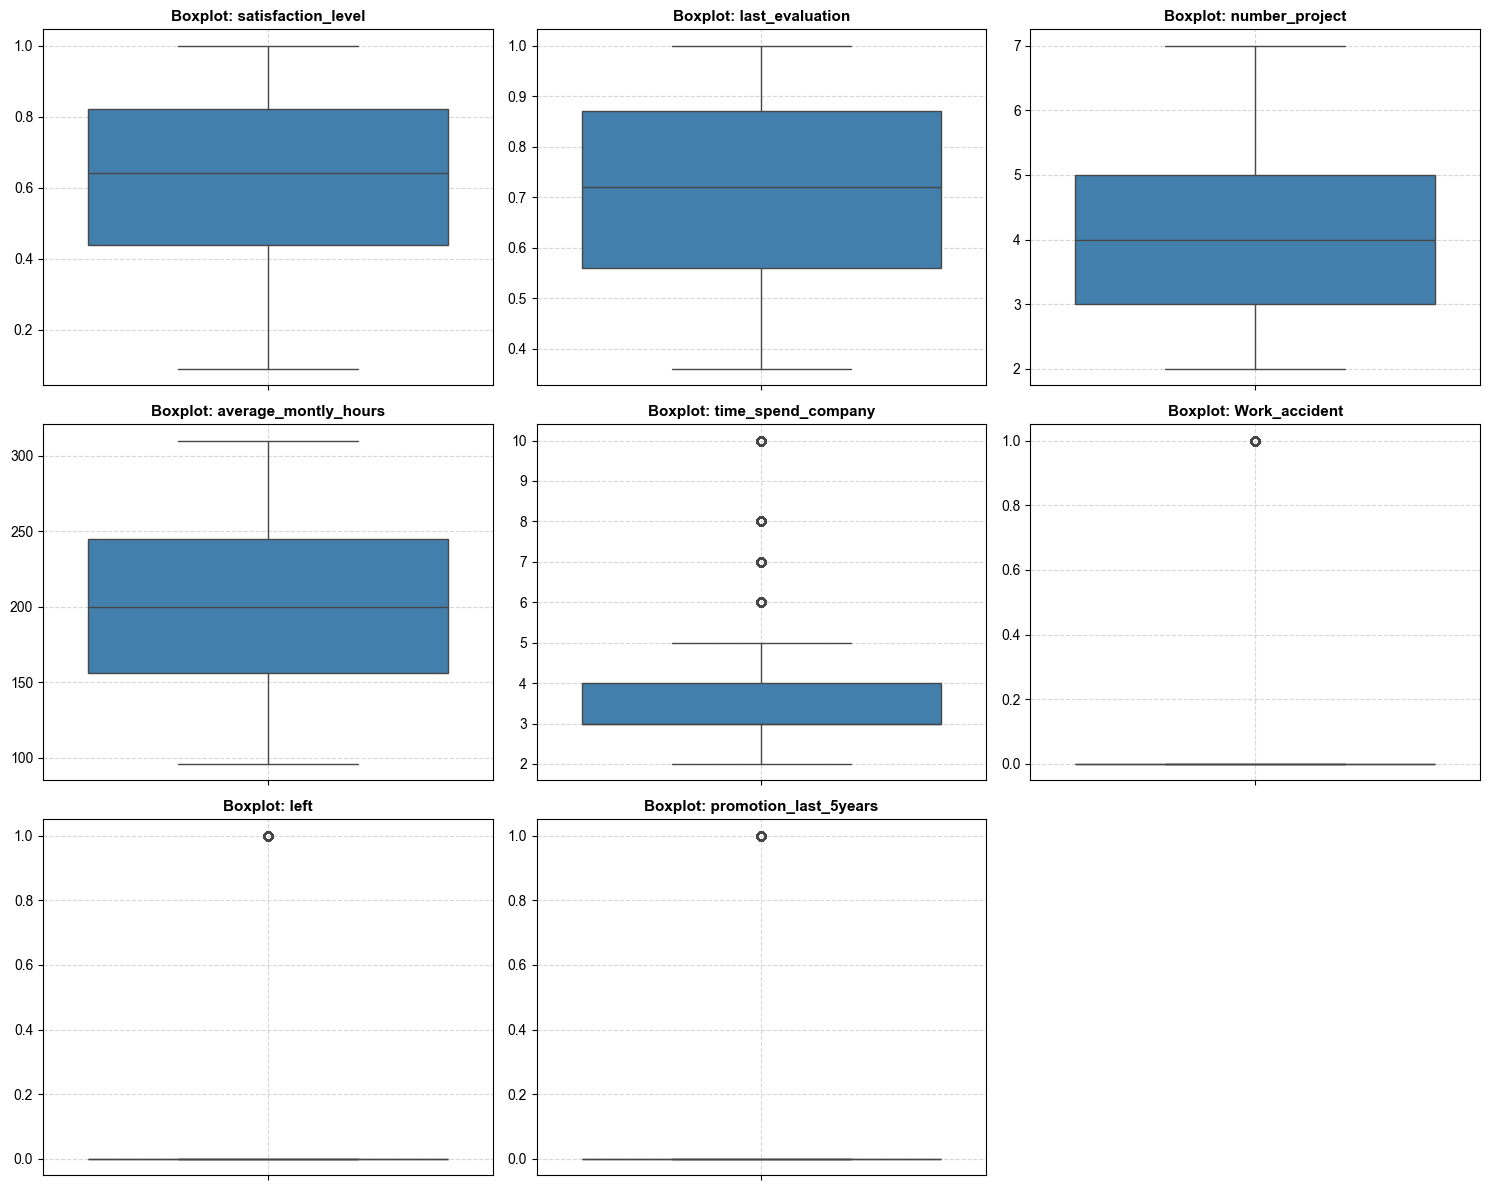

In [4]:
check_dataframe_boxplot(df0, show_head=False)

### 2.2 Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df0.rename(columns={'Work_accident':'work_accident',
                    'average_montly_hours':'average_monthly_hours',
                    'Department':'department'}, inplace=True)


# Display all column names after the update
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### 2.3 Check duplicates

Check for any duplicate entries in the data.

In [7]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [8]:
duplicates_group = (
    df0.groupby(df0.columns.to_list())
    .size()
    .reset_index(name='count')
)
duplicates_group = duplicates_group[duplicates_group['count'] > 1]

duplicates_group['count'].describe()

count    2338.000000
mean        2.286570
std         0.462546
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: count, dtype: float64

In [9]:
duplicates_group['count'].value_counts().sort_index()

count
2    1676
3     656
4       5
6       1
Name: count, dtype: int64

#### Observations on duplicated values:

> Most duplicated records appear only a small number of times. Specifically, 1,676 unique profiles are duplicated twice and 656 profiles are duplicated three times, while only a few profiles appear four or six times. Since there are no large duplicate groups (e.g., dozens or hundreds of identical records), these duplicates are more likely to represent different employees sharing the same characteristics rather than data duplication caused by ETL or data quality issues.

### 2.4 Check outliers

Check for outliers in the data.

In [10]:
# Determine the number of rows containing outliers
q1, q3 = df0['time_spend_company'].quantile([0.25,0.75])
lower_bound = q1 - 1.5*(q3 - q1)
upper_bound = q3 + 1.5*(q3 - q1)

outliers = df0.loc[(df0['time_spend_company'] < lower_bound) | (df0['time_spend_company'] > upper_bound), 'time_spend_company']
outliers.describe()

count    1282.000000
mean        7.067083
std         1.478503
min         6.000000
25%         6.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: time_spend_company, dtype: float64

1. The dataset I was provided to analyze has 14,999 entries and 10 variables (10 columns), including a target variable (`left`) which is in binary format and 9 predictors which includes 7 numeric and 2 categorical variables.<br>
2. There are noticeably 3,008 duplicated rows which accounts for 20% the dataset. However, duplicate records do not appear to be caused by a systematic ETL issue, as nearly all duplicate groups occur only 2–3 times and no profile is repeated excessively. This suggests that the duplicates may represent different employees with identical attributes rather than erroneous duplicate entries. Therefore, retaining duplicates is a reasonable choice for preserving the original data distribution.
3. There are 1,282 outlier values in `time_spend_company` variable. The distribution is right-skewed as most employees work for the company in 2-3 years, and few people stay longer than 5 years to 10 years. Certain types of models are more sensitive to outliers than others. We may consider to remove outliers for robustness when choosing model.

### 2.5 Data visualizations

In [11]:
# Get numbers of people who left vs. stayed
print(f"Numbers of people who left vs. stayed:\n{df0['left'].value_counts()}")

# Get percentages of people who left vs. stayed
print(f"\nPercentages of people who left vs. stayed:\n{df0['left'].value_counts(normalize=True)}")


Numbers of people who left vs. stayed:
left
0    11428
1     3571
Name: count, dtype: int64

Percentages of people who left vs. stayed:
left
0    0.761917
1    0.238083
Name: proportion, dtype: float64


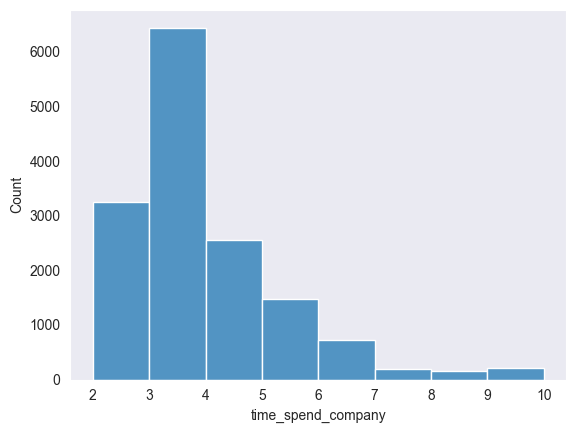

In [12]:
# Create a boxplot to visualize distribution of `time_spend_company`
sns.histplot(x=df0['time_spend_company'], binwidth=1);



Now, examine relationships and interactions between variables to reveal  
* Evaluate the strengthness of relationships between features and target outcome.
* Are the relationships linear or non-linear? <br>
* Do possible interactions exist that level up the effiency of the model?

In [13]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [14]:
categorical_cols = [
    'work_accident',
    'left',
    'promotion_last_5years',
    'department',
    'salary'
]

num_cols = [col for col in df0.columns if col not in categorical_cols]

First thing first, I wish to know the distribution of each numeric variable to see if there is any noticeable sign regarding data distribution.

In [15]:
def histogrammer(column_str, median_text=True, **kwargs): 
    median = round(df0[column_str].median(),1)

    plt.figure(figsize=(5,3))
    ax = sns.histplot(x=df0[column_str], **kwargs)
    plt.axvline(median, color='r', linestyle='--')
    if median_text:
        ymax = ax.get_ylim()[1]
        ax.text(x= median,
               y= ymax*0.9,
               s= f'Median: {median}',
               color='r',
               ha='left',
               va='top')
    else: 
        print(f'Median: {median}')
    plt.ylabel('')
    plt.title(f'Histogram of {column_str} distribution');

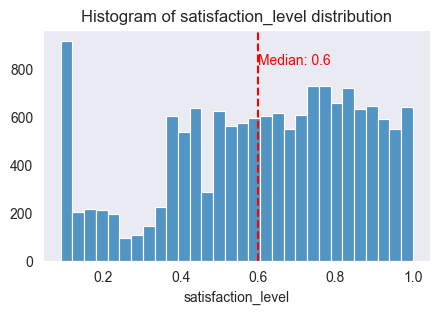

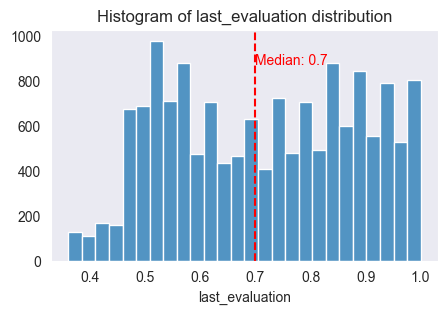

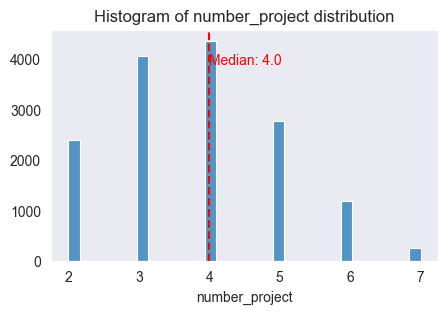

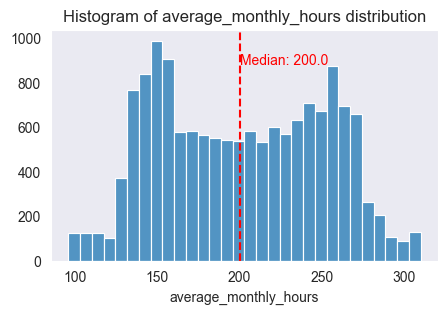

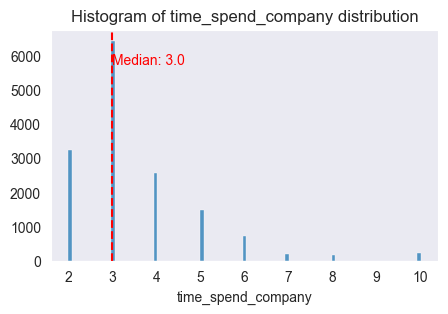

In [16]:
for col in num_cols: 
    histogrammer(col, median_text=True)

In [17]:
def review_difference_regarding_status(column_str: str, **kwargs): 
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
    # boxplot of distribution
    sns.boxplot(data=df0, x='left', y=col, hue='left', hue_order=[0,1], palette= ['green','grey'],ax=ax[0], legend=False)
    ax[0].set_xlabel('Stayed = 0 | Left = 1')

    # proportion of stayed and left people
    sns.histplot(data=df0, x= col, hue='left', hue_order=[0,1], palette={0:'green', 1:'grey'}, multiple='fill', ax=ax[1])
    ax[1].legend(title='status', labels=['stayed', 'left'], loc='upper left') # set the legend for both
    
    plt.tight_layout()
    plt.show()

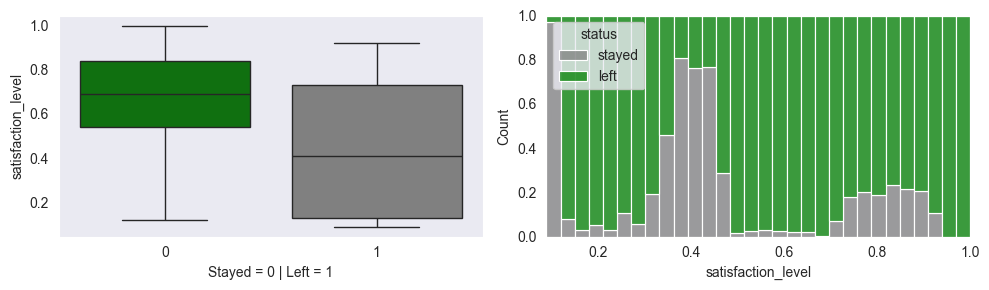

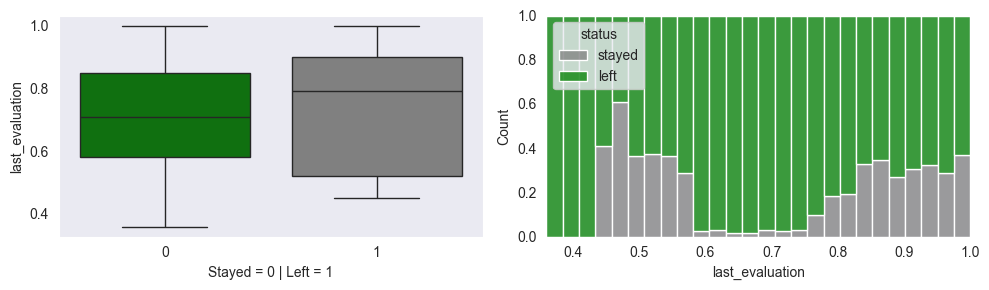

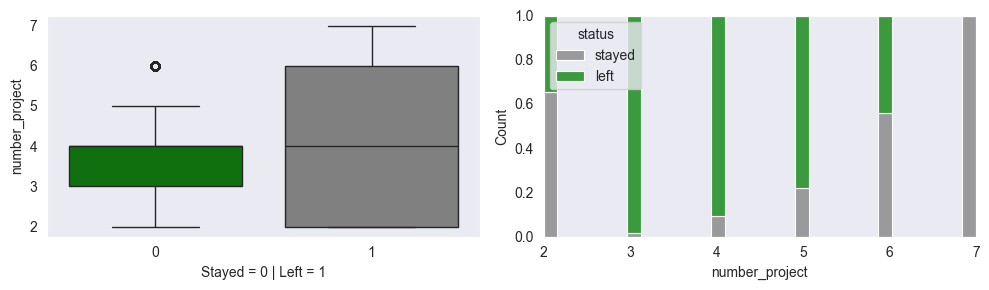

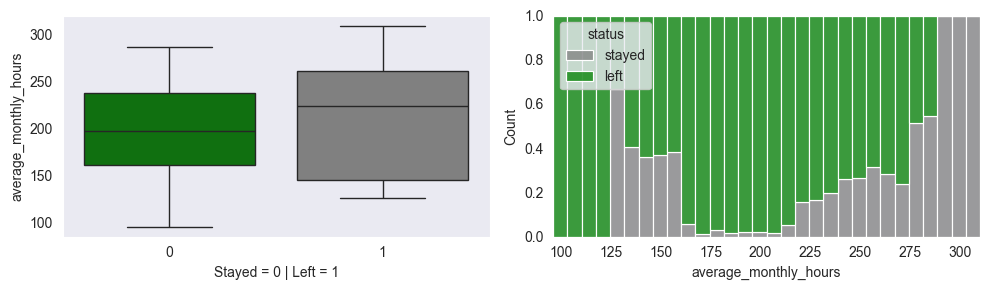

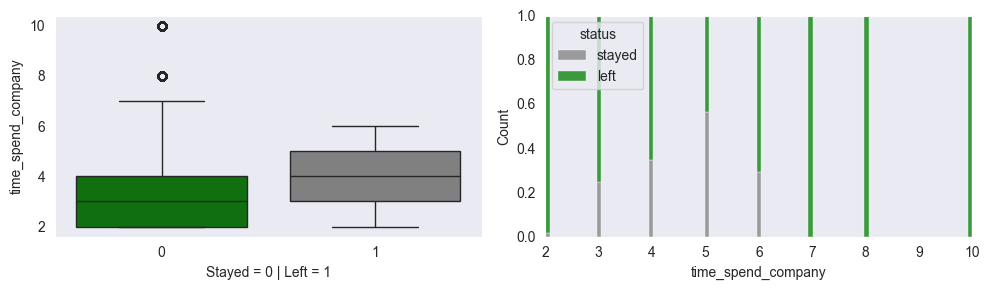

In [18]:
# review difference of distribution of each feature regarding stayed and left groups

for col in num_cols:
    review_difference_regarding_status(col)

In [19]:
df0.groupby('left').agg(avg_tenure = ('time_spend_company', 'mean'), 
                       avg_satisfaction = ('satisfaction_level', 'mean'), 
                       avg_evaluation = ('last_evaluation', 'mean'), 
                       avg_projects = ('number_project','mean'), 
                       avg_working_hours = ('average_monthly_hours','mean'))

,avg_tenure,avg_satisfaction,avg_evaluation,avg_projects,avg_working_hours
left,,,,,
0,3.380032,0.666810,0.715473,3.786664,199.060203
1,3.876505,0.440098,0.718113,3.855503,207.419210


> **Overall, none of the variables seemingly has a linear correlation with the target variable `left`.**
* Tangibly, employees with `lower satisfaction level` have a tendency to leave the company more than those who feel higher satisfaction. However, along the increase of satisfaction point, the proportion of left people outweighs people who stayed at the cohort of [0;0.25], then reverses the dimension and suprisingly bounces back at the point of approximately [0.3;0.425].
* Besides, we witness that the trends of other features and the target outcome (left or stayed) are non-linearity. For instance:
    * People who take extremely few (<3) or many projects (6-7) decided to leave the company more often as a few means boredom but many may lead to overload and burnout. Especially, all the people who handle 7 projects left.
    * The similar conclusion can be withdrawn when it comes to average monthly working hours.
    * The median of tenure is 3 years: 5-year tenure is a critical milestone where the odds ratio of left peaks, whilst, all of employees retain once they surpass to the seventh year or further.

#### Explore insights between number of projects and average working hours per month

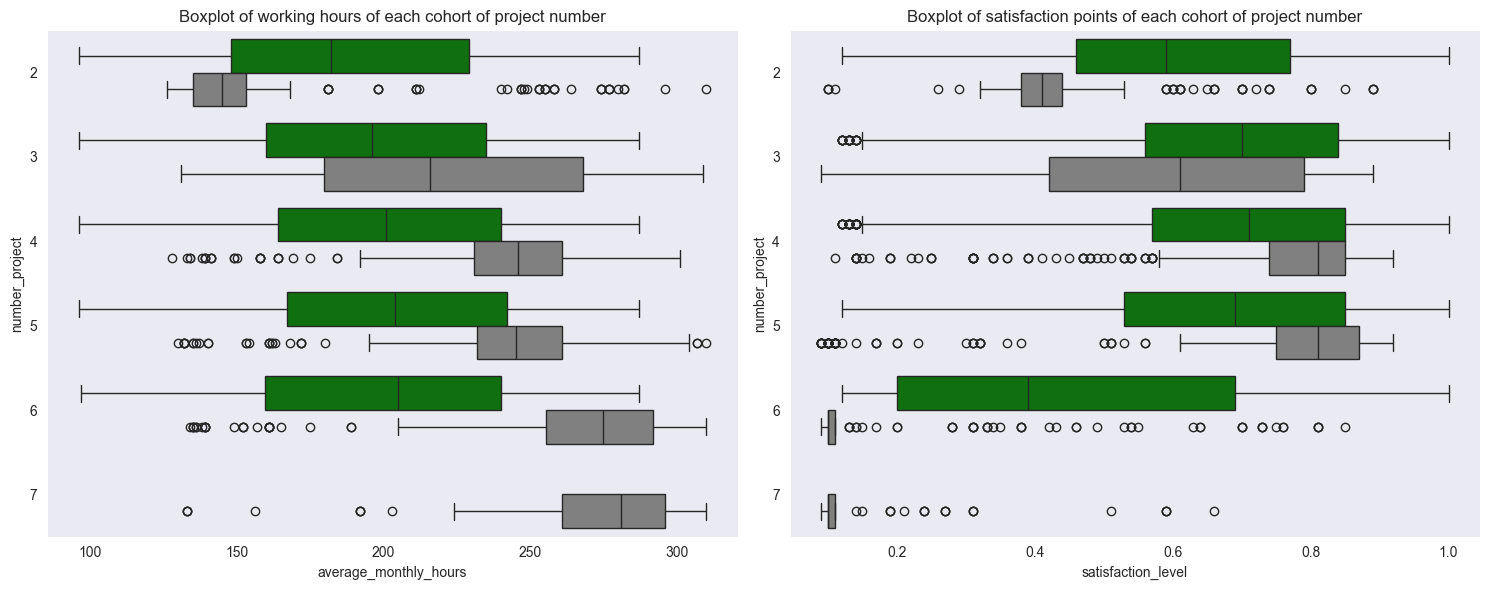

In [20]:
# explore boxplot of satisfaction_level of each cohort of project number

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
sns.boxplot(data=df0,
           x='average_monthly_hours',
           y='number_project',
            hue='left',
            orient='h',
            legend=False,
            palette=['green','grey'],
           ax=ax[0])
ax[0].set_title('Boxplot of working hours of each cohort of project number')

sns.boxplot(data=df0,
           x='satisfaction_level',
           y='number_project',
            hue='left',
            orient='h',
            legend=False,
            palette=['green','grey'],
           ax=ax[1])
ax[1].set_title('Boxplot of satisfaction points of each cohort of project number')

plt.tight_layout()
plt.show()

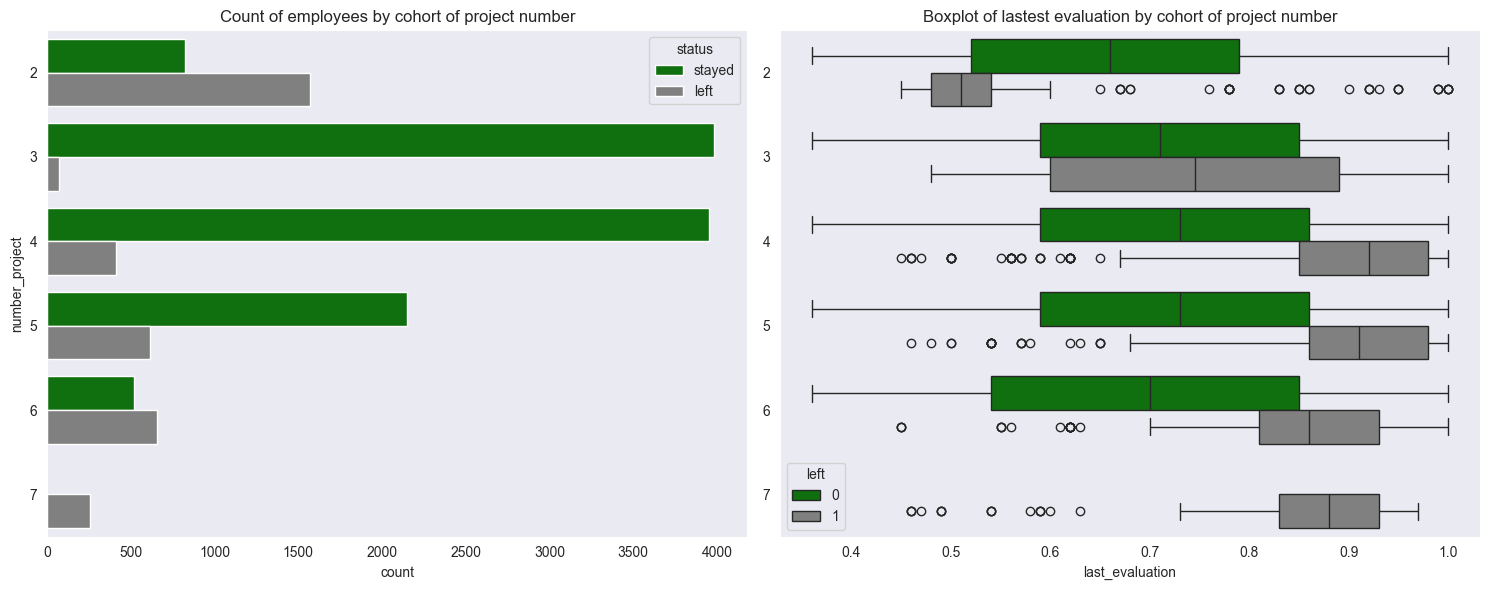

In [21]:
# explore boxplot of satisfaction_level of each cohort of project number

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
sns.countplot(data=df0, 
             y='number_project',
             hue='left',
              palette=['green','grey'],
             ax=ax[0])
ax[0].legend(['stayed','left'], title='status')
ax[0].set_title('Count of employees by cohort of project number')

sns.boxplot(data=df0,
           x='last_evaluation',
           y='number_project',
            hue='left',
            palette=['green','grey'],
            orient='h',
           ax=ax[1])
ax[1].set_ylabel('')
ax[1].set_title('Boxplot of lastest evaluation by cohort of project number')

plt.tight_layout()
plt.show()

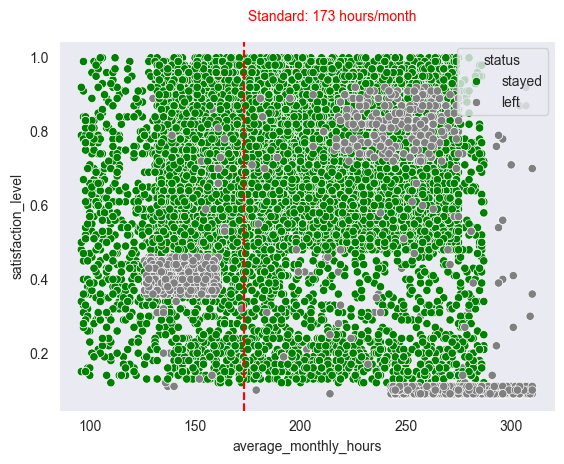

In [22]:
ax = sns.scatterplot(
    data=df0,
    x='average_monthly_hours',
    y='satisfaction_level',
    hue='left',
    palette={0:'green', 1:'grey'}
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ['stayed', 'left'],
    title='status'
)

plt.axvline(x=173, linestyle='--', color='r')
plt.text(x=175, y=1.1, s='Standard: 173 hours/month', color='r')
plt.show()

#### Key Insights:

**The boxplots indicate a clear relationship between project workload, working hours, performance, satisfaction level, and employee attrition. Three distinct groups of employees who left the company can be observed:**

1. **Employees handling 6-7 projects:** Employees who left in this group worked significantly longer hours than those who stayed, averaging 250-300 hours per month, well above the standard workload. Despite being high performers with strong evaluation scores, they reported extremely low satisfaction levels (<0.2). **This suggests that burnout and excessive workload were likely key drivers of decision to leave in this cohort.**

3. **Employees handling 4-5 projects:** Employees who left in this cohort were also generally high performers and worked longer hours than those who stayed. However, unlike the previous group, they maintained relatively high satisfaction levels. **This suggests that workload was not the primary reason for leaving, and factors such as career growth, compensation, or external opportunities may have played a larger role.**

4. **Employees handling 2 projects:** Employees who left in this group were typically lower performers, worked fewer hours than average, and reported satisfaction levels below 0.5. While lower workload may have contributed to weaker performance, the findings also suggest a possible lack of engagement or limited development opportunities. **These employees may have felt underutilized and dissatisfied with their role.**

Note on employees handling 3 projects:
 This group was excluded from the main analysis because employees who left represented a very small proportion of the cohort. In addition, the characteristics of employees who left and those who stayed were relatively similar, with no strong patterns observed. Their turnover is therefore less likely to be explained by workload-related factors and may be driven by individual circumstances.

> **Overall, the findings suggest that employee turnover is not driven by a single factor.** Instead, attrition appears to stem from at least two distinct pathways: burnout among highly utilized top performers and disengagement among underutilized lower performers.

### Explore correlation between salary, promotion & tenure:

As information being shown above, we've known that there is a barrier at 6 years of tenure. All employees who surpassed the sixth year at the company continued to stay. We'll see if salary and promotion are strong motivations for long-term commitment.

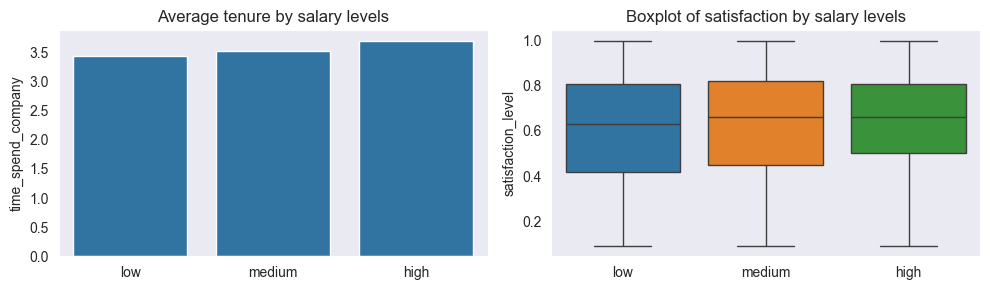

In [23]:
# review trends of salary level
fig, ax = plt.subplots(1,2, figsize=(10,3))

#bar chart of mean value
sns.barplot(data=df0
           , x='salary'
           , y='time_spend_company'
           , estimator='mean'
           , ci=False
           , ax=ax[0])
ax[0].set_xlabel('')
ax[0].set_title('Average tenure by salary levels')

#boxplot of 3 cohorts: high, medium, and low salary 
sns.boxplot(data=df0
           , x='salary'
           , y='satisfaction_level'
           , hue='salary'
           , ax=ax[1])
ax[1].set_xlabel('')
ax[1].set_title('Boxplot of satisfaction by salary levels')

plt.tight_layout()
plt.show()

In [24]:
salary_by_tenure = pd.crosstab(index=df0['time_spend_company']
           , columns=df0['salary']
           , normalize='index')
salary_by_tenure = salary_by_tenure[['high','medium','low']]
salary_by_tenure

salary,high,medium,low
time_spend_company,,,
2,0.093403,0.435882,0.470715
3,0.080708,0.421853,0.497439
4,0.067657,0.423934,0.508408
5,0.044807,0.412763,0.542430
6,0.076602,0.459610,0.463788
7,0.202128,0.606383,0.191489
8,0.111111,0.518519,0.370370
10,0.299065,0.439252,0.261682


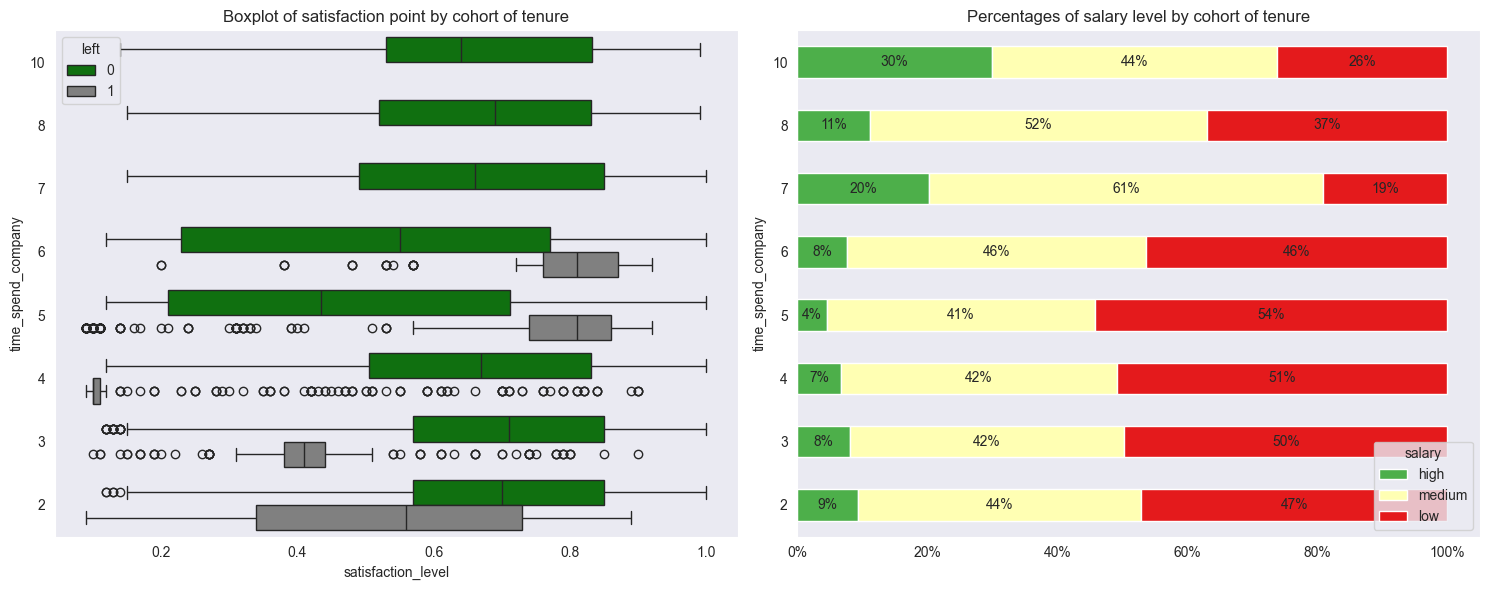

In [25]:
# explore satisfaction point and proportion of salary by cohort of tenure
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
order = sorted(df0['time_spend_company'].unique(), reverse=True)
sns.boxplot(data=df0
           , y='time_spend_company'
           , x='satisfaction_level'
           , orient='h'
           , hue='left'
            , order=order
           , palette=['green', 'grey']
           , ax=ax[0])
ax[0].set_title('Boxplot of satisfaction point by cohort of tenure')

salary_by_tenure.plot(
    kind='barh'
    , stacked=True
    , color= ['#4daf4a','#ffffb3','#e41a1c']
    , ax= ax[1]
)

for c in ax[1].containers:
    ax[1].bar_label(
        c,
        fmt=lambda x: f'{x:.0%}' if x > 0.03 else '',
        label_type='center'
    )
    
ax[1].set_title('Percentages of salary level by cohort of tenure')
ax[1].xaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

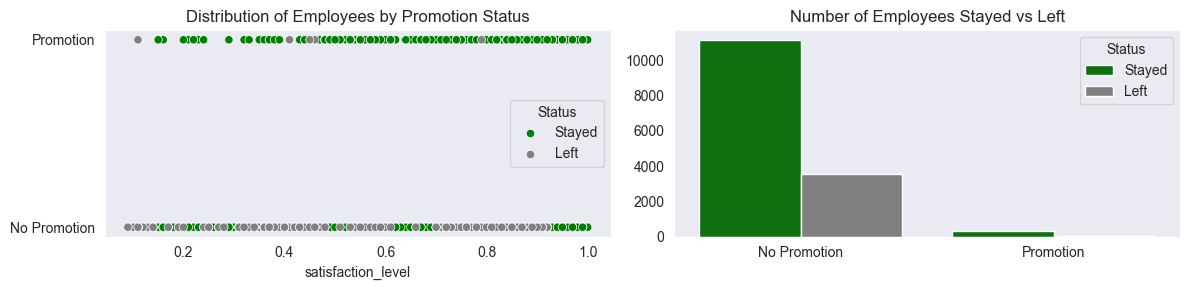

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))

# Scatter plot
sns.scatterplot(
    data=df0,
    x='satisfaction_level',
    y='promotion_last_5years',
    hue='left',
    palette={0: 'green', 1: 'grey'},
    ax=ax[0]
)

handles, labels = ax[0].get_legend_handles_labels()

ax[0].set_yticks([0, 1])
ax[0].set_yticklabels(['No Promotion', 'Promotion'])
ax[0].legend(handles, ['Stayed', 'Left'], title='Status')
ax[0].set_ylabel('')
ax[0].set_title(
    'Distribution of Employees by Promotion Status'
)

# Count plot
sns.countplot(
    data=df0,
    x='promotion_last_5years',
    hue='left',
    palette={0: 'green', 1: 'grey'},
    ax=ax[1]
)

handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles, ['Stayed', 'Left'], title='Status')

ax[1].set_xticklabels(['No Promotion', 'Promotion'])
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].set_title('Number of Employees Stayed vs Left')

plt.tight_layout()
plt.show()

In [27]:
pd.crosstab(index=df0['promotion_last_5years']
           , columns=df0['left']
           , margins=True
           )

left,0,1,All
promotion_last_5years,,,
0,11128,3552,14680
1,300,19,319
All,11428,3571,14999


#### Key Insights:

Salary and promotion appear to have a moderate influence on employee satisfaction and long-term commitment, but neither factor alone fully explains employee turnover.

1. **Salary has a limited impact on satisfaction:** Average employees' tenure follow the expected pattern of High Salary > Medium Salary > Low Salary, but the gaps are relatively small. Besides, the satisfaction distributions across the three salary groups are also broadly similar, suggesting that salary alone does not significantly differentiate how satisfied employees feel about their jobs.

2. **Long-tenured employees show stronger retention and better compensation:** No employees with 7 or more years of tenure left the company. These long-tenured cohorts also enjoy noticeably better compensation, with 60-80% of employees receiving either medium or high salaries. In contrast, employees with shorter tenure are predominantly in the low-salary group, while the proportion of high-salary employees generally remains below 10%. Among employees with 10 years of tenure, the share of high-salary employees rises to nearly 30%, indicating a strong link between tenure, compensation growth, and employee retention.

3. **Promotion is associated with lower turnover, but opportunities are limited:** Employees who received a promotion within the last five years showed a very low turnover rate of just 5%. However, promotion opportunities appear to be highly selective, with only 3% of all employees (319 individuals) receiving a promotion during this period. This suggests that while promotion can be an effective retention mechanism, its overall impact is constrained by the small number of employees who benefit from it.

**Overall, the findings suggest that salary and promotion contribute to long-term employee retention, but their influence on day-to-day job satisfaction is less pronounced than factors such as workload, engagement, and work experience highlighted in the previous analysis.**

### Turnover in departments

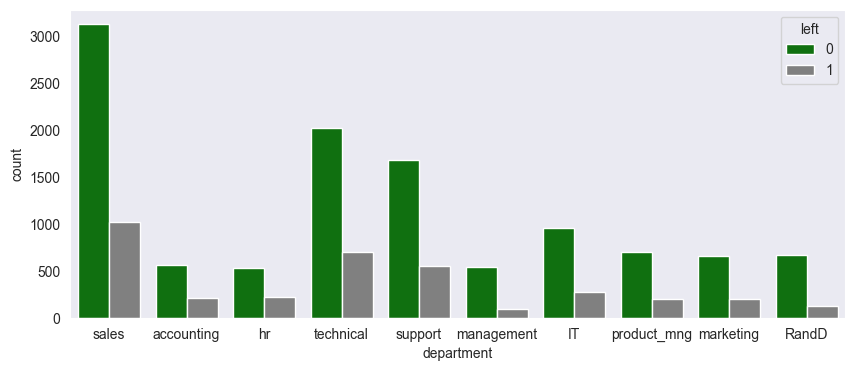

In [28]:
# number of employees who stayed and left in all departments 
plt.figure(figsize=(10,4))
sns.countplot(data=df0
             , x='department'
             , hue='left'
             , palette={0:'green'
                       , 1:'grey'})
plt.show()

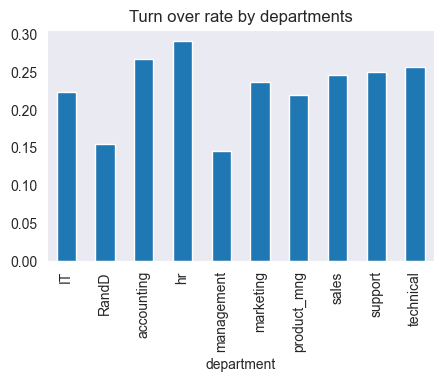

In [29]:
# turn over rate by departments
df0.groupby('department')['left'].mean().plot(
    kind='bar'
    , figsize=(5,3)
)
plt.title('Turn over rate by departments')
plt.show()

> There doesn't seem to be any department that differs significantly in its proportion of employees who left to those who stayed.

Before moving on building model stage, I wish to check correlation strength between variables in the dataset.

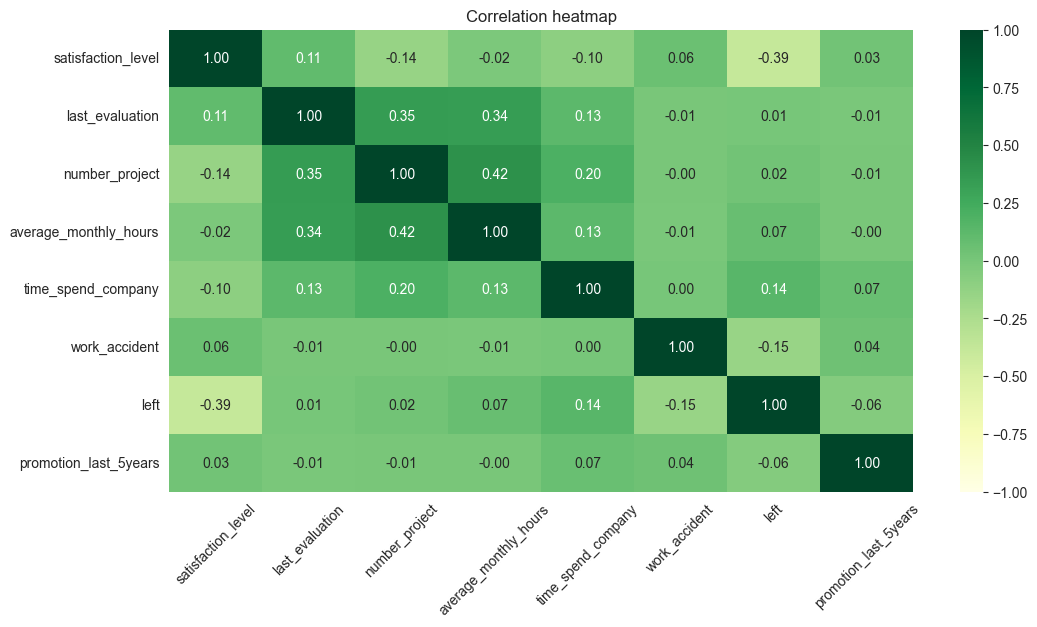

In [30]:
plt.figure(figsize=(12,6))
sns.heatmap(data=df0.corr(numeric_only=True)
           , vmax=1
           , vmin=-1
           , annot=True
           , fmt=".2f"
           , cmap='YlGn'
           , cbar=True)
plt.title('Correlation heatmap')
plt.xticks(rotation=45)
plt.show()

### **EDA summary:**

* The EDA suggests that employee turnover is influenced by a combination of employee satisfaction, workload, performance, and career-related factors. Correlation analysis shows that workload-related variables (`number_project`, `average_monthly_hours`, and `last_evaluation`) are closely connected, while satisfaction_level stands out as the single strongest individual factor associated with employees leaving the company. The exploratory analysis also revealed several non-linear patterns and potential feature interactions that may not be fully captured by a simple linear model.<br>
* **The next step is to evaluate predictive models that can both quantify key drivers and capture these complex interactions.**

## **Step 3. Model Building, Results and Evaluation**
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### 3.1 Identify the types of models most appropriate for this task.

Because the outcome target is categorical and binary, I would perform 3 different models on the dataset, then find a champion model that works most efficiently and meets the requirements of stakeholders. The models are as follows:
* Logistic Regression
* Random Forest
* XGBoost

To avoid any possibility of data leakage, I would iterably instantiate X and y for each performance, using the same parameters: `test_size = 0.3`, `validition_size = 0.25*0.7` and `random_state=42`.

**Logistic Regression**
- Outcome variable is categorical.
- Observations are independent of each other.
- Requires no severe multicollinearity among prediction variables(X).
- No extreme outliers.
- Sufficiently large sample size<br>
**Due to the assumption of no extreme outliers, I would tackle outliers in `time_spend_company` variable. Other assumptions are met.**<br>

**Random Forest**
* Random Forest ensemble requires no assumptions regarding distribution of data.
* Tree-based model like Random Forest can easily handle multicolinearity.
* Like other computation learning models, Random Forest requires numeric input, so encoding is a must if there is categorical data.

**XGBoost**
* Like Random Forest, XGBoost also requires few preprocessing data.
* Robust to outliers & multicollinearity.
* Not requires data to be scaled or normalized.

### 3.2 Modeling 01: Logistic Regression

In [31]:
# Import additional relevant packages

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import statsmodels.api as sm

#### Preprocessing: encode `department` and `salary` & review assumptions

In [32]:
df1 = df0.copy()

# drop the duplicates
df1 = df1.drop_duplicates(keep='first')

df1.shape

(11991, 10)

In [33]:
# department: nominal variable => one-hot encoding
df1 = pd.get_dummies(df1
                    , columns=['department']
                    , drop_first=True)

# salary: ordinal variable as high > medium > low 
salary_map = {'low':1
             , 'medium': 2
             , 'high': 3}
df1['salary'] = df1['salary'].map(salary_map)

# check results
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,1,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,2,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,2,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,1,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,1,False,False,False,False,False,False,True,False,False


In [34]:
# remove outliers in time_spend_company 

df1 = df1.loc[(df1['time_spend_company']>= lower_bound) & (df1['time_spend_company'] <= upper_bound)].reset_index(drop=True)
df1.head(2)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,1,False,False,False,False,False,False,True,False,False
1,0.11,0.88,7,272,4,0,1,0,2,False,False,False,False,False,False,True,False,False


In [35]:
df1.shape

(11167, 18)

#### Build Logistic Regression model

In [36]:
# create X and y
y = df1['left']
X = df1.drop(columns=['left'])

In [37]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [38]:
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,salary,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,1,False,False,False,False,False,False,True,False,False
1,0.11,0.88,7,272,4,0,0,2,False,False,False,False,False,False,True,False,False
2,0.72,0.87,5,223,5,0,0,1,False,False,False,False,False,False,True,False,False
3,0.37,0.52,2,159,3,0,0,1,False,False,False,False,False,False,True,False,False
4,0.41,0.50,2,153,3,0,0,1,False,False,False,False,False,False,True,False,False


In [39]:
# split the dataset into 3 subsets
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(X, y
                                                   , test_size= 0.3
                                                   , stratify=y
                                                   , random_state=42)

X_log_tr, X_log_val, y_log_tr, y_log_val = train_test_split(X_log_train, y_log_train, 
                                                           test_size = 0.25, 
                                                           stratify=y_log_train, 
                                                           random_state=42)

In [40]:
for x in [X_log_tr, X_log_val,X_log_test]: 
    print(len(x))

5862
1954
3351


In [41]:
# fit the model 

logistic_clf = LogisticRegression(random_state=42).fit(X_log_tr, y_log_tr)

In [42]:
# use the regression model to get predictions on the test set 

y_pred = logistic_clf.predict(X_log_val)

#### Evaluate the Logistic Regression model

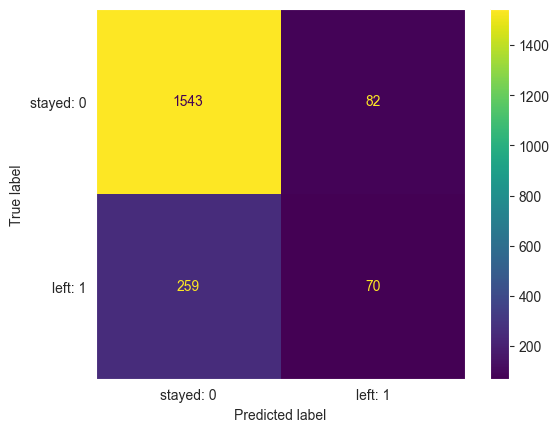

In [43]:
# draw a confusion matrix 

log_cm = metrics.confusion_matrix(y_log_val, y_pred, labels=logistic_clf.classes_)

log_cm_disp = metrics.ConfusionMatrixDisplay(confusion_matrix= log_cm
                                            , display_labels=['stayed: 0', 'left: 1'])
log_cm_disp.plot(values_format='')
plt.show()

* True Positives (employees who are predicted as left and actually left): 70
* False Positives (employees who are predicted as left but NOT left): 82
* True Negatives (employees who are predicted as stayed and actually stayed): 1543
* False Negatives (employees who are predicted as stayed but actually left): 259 <br>
At a quick glance, I can see that the model achieves poor recall and precision on predicting people who leave.

In [44]:
# call out a summary report table 

target_names = ['Predicted as stayed', 'Predicted as left']
print(metrics.classification_report(y_log_val
                                   , y_pred
                                   , target_names=target_names))

                     precision    recall  f1-score   support

Predicted as stayed       0.86      0.95      0.90      1625
  Predicted as left       0.46      0.21      0.29       329

           accuracy                           0.83      1954
          macro avg       0.66      0.58      0.60      1954
       weighted avg       0.79      0.83      0.80      1954



In [45]:
models_summary = pd.DataFrame({
    'model': ['Logistic Regression, thre=0.5'],
    'precision': [metrics.precision_score(y_log_val, y_pred)],
    'recall': [metrics.recall_score(y_log_val, y_pred)],
    'f1': [metrics.f1_score(y_log_val, y_pred)], 
    'accuracy': [metrics.accuracy_score(y_log_val, y_pred)], 
    'roc_auc': [metrics.roc_auc_score(y_log_val, y_pred)]
})

models_summary

,model,precision,recall,f1,accuracy,roc_auc
0,"Logistic Regression, thre=0.5",0.460526,0.212766,0.29106,0.825486,0.581152


**The current model achieves 82% accuracy, yet poorly predicts to identify employees who actually left, with a recall of only 24% and a precision of 46% for the left class.**<br>
Assuming that (after talking to HR stakeholders) the priority was defined as maximizing the identification of potential turnover cases rather than minimizing false alarms, I would try to adjust the classification threshold to increase recall and capture a larger proportion of employees who may be at risk of leaving.

#### Adjust the threshold

In [46]:
# get the probability of the model
y_prob = logistic_clf.predict_proba(X_log_val)[:,1]
y_prob

array([0.09971336, 0.07923469, 0.21274818, ..., 0.01223471, 0.08756181,
       0.15721985], shape=(1954,))

The default threshold is 0.5 which means that if P(1|X) >= 0.5 then the model will predict y as 1. By lowering this threshold, the model will be able to catch more True Positives but at the same time, False Positives will increase. Basically, this is a trade-off situation where we need to consider between the cost of missing True Positives and the cost of facing False Positives; or in this practical situation, we are dealing with the cost of missing actual left employees and the cost of getting false signal of staying employees.

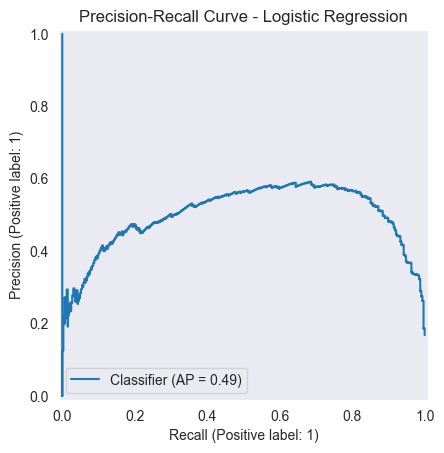

In [47]:
# plot recall-precision curve 

metrics.PrecisionRecallDisplay.from_predictions(
    y_log_val,
    y_prob
)

plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()

* From the Precision-Recall curve above, we can see that the optimal option falls approximately in the range of 0.6-0.8 recall, where the precision is still pretty good (above 60%). If we push recall to higher than 0.8, the precision drops sharply which means we face significantly much more false alarms and I believe that HR will not love it!<br>
* AP= 0.49 which means that Average Precision = 0.49. This metric indicates that the model maintains precision while changing recall, averaging at 49%.

In [48]:
# establish a table of precision & recall according to each threshold
# find the threshold where recall is closet to 0.8 and the precision is highest
precision, recall, threshold = metrics.precision_recall_curve(y_log_val, y_prob)

pr_table = pd.DataFrame({
    'threshold': threshold, 
    'precision': precision[:-1], 
    'recall': recall[:-1]
})
pr_table = pr_table[pr_table['recall']>=0.8].sort_values('precision', ascending=False)
pr_table.head(1)

,threshold,precision,recall
1483,0.246345,0.566879,0.81155


In [49]:
best_thre = pr_table.loc[1483,'threshold']
best_thre

np.float64(0.2463453338607972)

In [50]:
# get new predictions and new results
new_pred = [1 if x >= best_thre else 0 for x in y_prob]

print(metrics.classification_report(
    y_log_val, 
    new_pred, 
    target_names=target_names
))

                     precision    recall  f1-score   support

Predicted as stayed       0.96      0.87      0.91      1625
  Predicted as left       0.57      0.81      0.67       329

           accuracy                           0.86      1954
          macro avg       0.76      0.84      0.79      1954
       weighted avg       0.89      0.86      0.87      1954



In [51]:
models_summary.loc[len(models_summary)] = [
    'Logistic Regression, thre=0.255',
    metrics.precision_score(y_log_val, new_pred),
    metrics.recall_score(y_log_val, new_pred),
    metrics.f1_score(y_log_val, new_pred), 
    metrics.accuracy_score(y_log_val, new_pred),
    metrics.roc_auc_score(y_log_val, new_pred)
]
models_summary

,model,precision,recall,f1,accuracy,roc_auc
0,"Logistic Regression, thre=0.5",0.460526,0.212766,0.29106,0.825486,0.581152
1,"Logistic Regression, thre=0.255",0.566879,0.811550,0.66750,0.863869,0.843006


#### **Summary:**
**Lowering the classification threshold from 0.50 to 0.255** significantly improved the model's ability to identify employees at risk of leaving, **increasing recall from 21% to 81%**.<br> At the same time, **precision improved slightly from 46% to 56%**, indicating that the model became more effective at detecting potential turnover cases without sacrificing prediction quality.<br> **This threshold was therefore selected as it better aligns with HR's objective of proactively identifying employees who may be at risk of leaving.**

#### Interprete the coeficients:

In [52]:
# Establish a table of features & coeficient of the Logistic model 

coef_df = pd.DataFrame({
    'features': X_log_train.columns, 
    'coefficient': logistic_clf.coef_[0]
})
coef_df = coef_df.sort_values(by='coefficient', ascending=False)
coef_df

,features,coefficient
4,time_spend_company,1.113833
16,department_technical,0.136702
14,department_sales,0.115600
10,department_hr,0.107934
15,department_support,0.075716
3,average_monthly_hours,0.004633
9,department_accounting,-0.117229
12,department_marketing,-0.141280
11,department_management,-0.184006
6,promotion_last_5years,-0.281608


In fact, the Logistic Regression assumes that there is linearity relationship between each X variable with the logit of the probability that Y=1 (p).<br>
$$
logit(p) = log(\frac{p}{1-p}) = \beta_0 + \beta_1*X_1
$$
Therefore, the coefficients ($\beta_1$) currently show the linearity with log of odds ratio p.

In [53]:
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df

,features,coefficient,odds_ratio
4,time_spend_company,1.113833,3.046010
16,department_technical,0.136702,1.146486
14,department_sales,0.115600,1.122547
10,department_hr,0.107934,1.113974
15,department_support,0.075716,1.078656
3,average_monthly_hours,0.004633,1.004644
9,department_accounting,-0.117229,0.889382
12,department_marketing,-0.141280,0.868246
11,department_management,-0.184006,0.831931
6,promotion_last_5years,-0.281608,0.754570


#### **Interpretation Summary:**
* Employee satisfaction is the strongest predictor: a 0.1-point increase in satisfaction_level is associated with approximately 34% lower odds of leaving, holding other variables constant.
* Employees with a work accident, a higher salary category, or a recent promotion also show lower odds of leaving, but not as a strong magtitude as satisfaction on their jobs.
* Each additional year at the company is associated with nearly 4 times higher odds of leaving, after controlling for the other variables.
* Department differences are relatively limited: Technical, Sales, and Support show slightly higher odds of leaving, while Accounting, Product Management, Marketing, Management, and R&D show lower odds, all relative to the omitted reference department.<br>

However, the counterintuitive coefficients for working hours, project count, and evaluation suggest that the model does not fully capture their non-linear and interaction effects. These results indicate associations, not causal relationships. **At this point, a different approach model like decision tree or random forest need to be involved, because the relationships are beyond a linear boundary decision to capture.**

### 3.3 Modeling 02: Random Forest model

In [54]:
# import relevant packages 
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import pickle

#### Write DEF to save models to pickle and restore models for further analysis

In [55]:
def write_pickle(path, model_object, save_as:str):
    '''
    In: 
        path:         path of folder where to save the pickle
        model_object: a model that needs to be pickled
        save_as:      filename for how to save the model

    Out: A call to pickle the model in the folder indicated
    '''    

    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [56]:
def read_pickle(path, saved_model_name:str):
    '''
    In: 
        path:             path to folder where you want to read from
        saved_model_name: filename of pickled model you want to read in

    Out: 
        model: the pickled model 
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

#### Split the dataset into 3 subsets for training, validating, and testing

In [57]:
y_rf = df1['left']
X_rf = df1.drop(columns=['left'])

In [58]:
# split the train set into train, validation and test set
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, 
                                                               y_rf, 
                                                               test_size=0.3, 
                                                               stratify=y_rf, 
                                                               random_state=42)

X_rf_tr, X_rf_val, y_rf_tr, y_rf_val = train_test_split(X_rf_train,
                                                       y_rf_train, 
                                                       test_size=0.25, 
                                                       stratify=y_rf_train, 
                                                       random_state=42)

#### Hyperparameter tuning using GridSearchCV

In [59]:
# instantiate classifier 
rf = RandomForestClassifier(random_state=42)

In [60]:
# hyperparemater tuning 
# 1. declare hyperparam 2. create a set of scores 3. instantiate GridSearchCV

cv_params = {
    'n_estimators':[300,500], 
    'max_depth': [5,10,None], 
    'min_samples_split': [2,5,10], 
    'min_samples_leaf': [1,2,5,10], 
    'max_features': ['sqrt', 0.5, 1.0]
}

scoring = {'roc_auc':'roc_auc', 
           'precision':'precision', 
           'f1':'f1', 
           'recall':'recall', 
           'accuracy':'accuracy'}

rf_cv = GridSearchCV(rf, 
                    cv_params, 
                    scoring=scoring, 
                    cv=4, 
                    refit='recall', 
                    n_jobs=-1,
                     return_train_score=True,
                    verbose=1)

In [61]:
%%time
# fit the GridSearch to training set
# rf_cv.fit(X_rf_tr, y_rf_tr)

CPU times: total: 0 ns
Wall time: 0 ns


In [64]:
# pickle the model 
path = r'D:\我的卧室\LEARNING DATA\10. GCC - Google Advanced Data Analytics\Course 6 - Capstone project'
# write_pickle(path, rf_cv, '\RF_cv')

In [66]:
# read the pickle 
rf_cv = read_pickle(path,'\RF_cv')

In [67]:
# return best score and best paramerters 

print('Best score:', rf_cv.best_score_)
print('Best parameters:', rf_cv.best_params_)

Best score: 0.9190283400809718
Best parameters: {'max_depth': 5, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [68]:
# append results to summary table
cv_results = pd.DataFrame(rf_cv.cv_results_)
best_indx = rf_cv.best_index_

models_summary.loc[len(models_summary)] = [
    'Random Forest CV',
    cv_results.loc[best_indx,'mean_test_precision'],
    cv_results.loc[best_indx,'mean_test_recall'],
    cv_results.loc[best_indx,'mean_test_f1'], 
    cv_results.loc[best_indx,'mean_test_accuracy'],
    cv_results.loc[best_indx,'mean_test_roc_auc']
]
models_summary

,model,precision,recall,f1,accuracy,roc_auc
0,"Logistic Regression, thre=0.5",0.460526,0.212766,0.291060,0.825486,0.581152
1,"Logistic Regression, thre=0.255",0.566879,0.811550,0.667500,0.863869,0.843006
2,Random Forest CV,0.956010,0.919028,0.937029,0.979188,0.981076


#### Validation

In [69]:
# best estimator to predict on validation set
y_rf_preds = rf_cv.best_estimator_.predict(X_rf_val)

In [70]:
def get_test_results(y_preds, y_test, model_name:str): 
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        y_preds: numpy array of test predictions
        y_test: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, accuracy, and roc_auc scores for your model
    '''
    precision = metrics.precision_score(y_test, y_preds)
    recall = metrics.recall_score(y_test, y_preds)
    accuracy = metrics.accuracy_score(y_test, y_preds) 
    f1 = metrics.f1_score(y_test, y_preds) 
    roc_auc = metrics.roc_auc_score(y_test, y_preds)

    table = pd.DataFrame({
        'model':[model_name], 
        'precision': [precision], 
        'recall': [recall], 
        'f1':[f1], 
        'accuracy': [accuracy], 
        'roc_auc': [roc_auc]
    })
    return table

In [71]:
rf_val_scores = get_test_results(y_rf_val, y_rf_preds, 'Random Forest val')
rf_val_scores

,model,precision,recall,f1,accuracy,roc_auc
0,Random Forest val,0.930091,0.974522,0.951788,0.984135,0.980249


In [72]:
models_summary = pd.concat([models_summary,rf_val_scores], axis=0).reset_index(drop=True)
models_summary

,model,precision,recall,f1,accuracy,roc_auc
0,"Logistic Regression, thre=0.5",0.460526,0.212766,0.291060,0.825486,0.581152
1,"Logistic Regression, thre=0.255",0.566879,0.811550,0.667500,0.863869,0.843006
2,Random Forest CV,0.956010,0.919028,0.937029,0.979188,0.981076
3,Random Forest val,0.930091,0.974522,0.951788,0.984135,0.980249


### 3.4 Modeling 03: XGBoost

In [73]:
# import additional relevant packages 

from xgboost import XGBClassifier, plot_importance


#### Split the dataset into 3 subsets

In [74]:
y_xgb = df1['left']
X_xgb = df1.drop(columns=['left'])

In [75]:
X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(X_xgb, y_xgb, 
                                                                   test_size=0.3, 
                                                                   stratify=y_xgb, 
                                                                   random_state=42)

X_xgb_tr, X_xgb_val, y_xgb_tr, y_xgb_val = train_test_split(X_xgb_train, y_xgb_train, 
                                                           test_size=0.25, 
                                                           stratify=y_xgb_train, 
                                                           random_state=42)

#### Hyperparameters tuning the XGBoost using GridSearchCV

In [76]:
# instantiate XGBoost model 
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

In [77]:
# hyperparemater tuning 
# 1. declare hyperparam 2. create a set of scores 3. instantiate GridSearchCV

xgb_params = {
    'max_depth':[4,6,8],
    'learning_rate':[0.05,0.1],
    'min_child_weight':[1,3,5],
    'n_estimators':[300,500],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0],
    'gamma':[0,0.1,0.3]
}

xgb_scoring = {'roc_auc':'roc_auc', 
           'precision':'precision', 
           'f1':'f1', 
           'recall':'recall', 
           'accuracy':'accuracy'}

xgb_cv = GridSearchCV(xgb,
                     xgb_params, 
                     scoring= xgb_scoring, 
                     cv=4, 
                     n_jobs=-1, 
                     refit='recall', 
                     return_train_score=True, 
                     verbose=1)

In [78]:
%%time 
# fit the GridSearch 
# xgb_cv.fit(X_xgb_tr, y_xgb_tr)

CPU times: total: 0 ns
Wall time: 0 ns


In [79]:
# save to pickle
# only UNCOMMENT when refitting the model
# write_pickle(path, xgb_cv, 'XGB_cv')

In [80]:
xgb_cv=read_pickle(path, '\XGB_cv')

In [81]:
print('Best recall:', xgb_cv.best_score_)
print('Best parameters:', xgb_cv.best_params_)

Best recall: 0.9180161943319838
Best parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}


In [82]:
# append best CV results to models_summary table
xgb_cv_results = pd.DataFrame(xgb_cv.cv_results_)
xgb_indx = xgb_cv.best_index_

models_summary.loc[len(models_summary)] = [
    'XGBoost CV',
    xgb_cv_results.loc[xgb_indx,'mean_test_precision'],
    xgb_cv_results.loc[xgb_indx,'mean_test_recall'],
    xgb_cv_results.loc[xgb_indx,'mean_test_f1'], 
    xgb_cv_results.loc[xgb_indx,'mean_test_accuracy'],
    xgb_cv_results.loc[xgb_indx,'mean_test_roc_auc']
]
models_summary

,model,precision,recall,f1,accuracy,roc_auc
0,"Logistic Regression, thre=0.5",0.460526,0.212766,0.291060,0.825486,0.581152
1,"Logistic Regression, thre=0.255",0.566879,0.811550,0.667500,0.863869,0.843006
2,Random Forest CV,0.956010,0.919028,0.937029,0.979188,0.981076
3,Random Forest val,0.930091,0.974522,0.951788,0.984135,0.980249
4,XGBoost CV,0.969005,0.918016,0.942766,0.981236,0.982508


#### Validation

In [83]:
y_xgb_preds = xgb_cv.best_estimator_.predict(X_xgb_val)

In [84]:
xgb_val_scores = get_test_results(y_xgb_preds, y_xgb_val, 'XGBoost Val')
xgb_val_scores

,model,precision,recall,f1,accuracy,roc_auc
0,XGBoost Val,0.96519,0.927052,0.945736,0.982088,0.960141


### 3.5 Summary of model results:

In [85]:
models_summary = pd.concat([models_summary, xgb_val_scores], axis=0).reset_index(drop=True)
models_summary

,model,precision,recall,f1,accuracy,roc_auc
0,"Logistic Regression, thre=0.5",0.460526,0.212766,0.291060,0.825486,0.581152
1,"Logistic Regression, thre=0.255",0.566879,0.811550,0.667500,0.863869,0.843006
2,Random Forest CV,0.956010,0.919028,0.937029,0.979188,0.981076
3,Random Forest val,0.930091,0.974522,0.951788,0.984135,0.980249
4,XGBoost CV,0.969005,0.918016,0.942766,0.981236,0.982508
5,XGBoost Val,0.965190,0.927052,0.945736,0.982088,0.960141


> **I recommend selecting Random Forest as the champion model because recall is the key success metric for this project.**
* Random Forest identified 97.5% of employees who left on the validation set, outperforming XGBoost’s 92.7% recall, while still maintaining a strong precision of 93.0%. This means HR can identify more at-risk employees and reduce missed opportunities for early retention actions, with only a moderate increase in false alerts.
* Although XGBoost achieved slightly higher precision, Random Forest provides the stronger business trade-off when the cost of overlooking a potential leaver is greater than the cost of investigating a false alert.
* Logistic Regression remains useful as an interpretable baseline, but its lower performance suggests that it does not fully capture the dataset’s non-linear patterns and feature interactions.

## Step 4. Results and Interpretation
- Interpret model
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Random Forest: Features importance

In [86]:
rf_importances = pd.DataFrame(
    rf_cv.best_estimator_.feature_importances_, 
    columns=['gini_importances'], 
    index=X.columns
)

rf_importances.sort_values(by='gini_importances', ascending=False)

rf_importances

,gini_importances
satisfaction_level,0.498253
last_evaluation,0.109675
number_project,0.171669
average_monthly_hours,0.057166
time_spend_company,0.160520
work_accident,0.000017
promotion_last_5years,0.000008
salary,0.000599
department_RandD,0.000123
department_accounting,0.000530


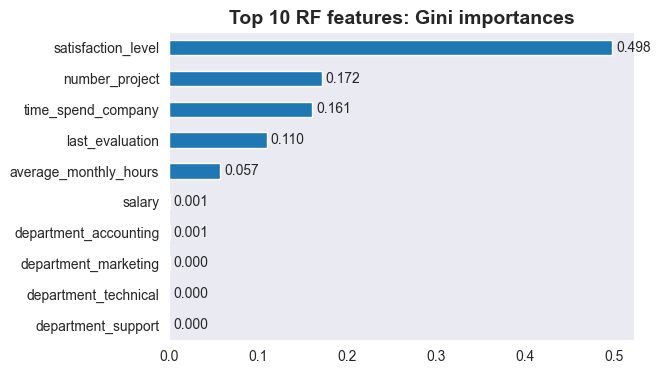

In [87]:
# visualize importances of top 10 features 

ax =(
    rf_importances.nlargest(10, 'gini_importances')
    .sort_values(by='gini_importances',ascending=True)
        .plot(
            kind='barh', 
            legend=False, 
            figsize=(6,4)
        )
)
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.3f',
        padding=3
    )
plt.title(
    'Top 10 RF features: Gini importances', 
    fontsize=14, 
    fontweight='bold'
)
plt.show()

* The plot above shows that in this Random Forest model, `job satisfaction`, `workload`, `latest performance`, and `tenure` are strong predictors in predicting the outcome target.
* Salary and department contribute relatively little compared with satisfaction and workload factors.<br>

**=> HR should prioritize monitoring employee satisfaction and workload balance, especially among employees with high project demands or tenure-related risk patterns.**

#### Additional: XGBoost feature importances

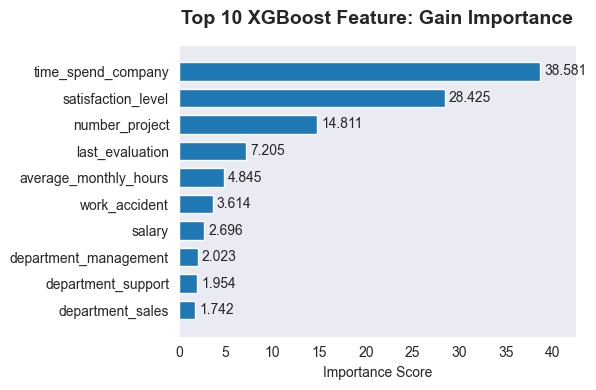

In [88]:
fig, ax1 = plt.subplots(figsize=(6,4))

plot_importance(
    xgb_cv.best_estimator_,
    importance_type='gain',
    max_num_features=10,
    height=0.7,
    show_values=False,
    grid=False,
    ax=ax1
)
for container in ax1.containers:
    ax1.bar_label(
        container, 
        fmt='%.3f',
        padding=3
    )
ax1.set_title(
    "Top 10 XGBoost Feature: Gain Importance",
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax1.set_xlabel("Importance Score")
ax1.set_ylabel("")

plt.tight_layout()
plt.show()

### Conclusion, Recommendations, Next Steps



> The analysis covered more than 11,000 employees across 11 departments, of whom approximately 26% had left the company.

#### **Key Findings:**

* **High performers represent a critical turnover risk.** One high-risk group managed **6-7 projects** and worked approximately **11-13 hours per day**, while reporting satisfaction levels **below 0.2 out of 1.0**. This combination indicates a strong pattern of prolonged overwork and declining job satisfaction.
* **Not all high-performing employees who left were dissatisfied.** Employees managing **4-5 projects** generally maintained higher satisfaction and worked fewer hours than the burnout group, but still left the company. This suggests that compensation, recognition, career progression, or external opportunities may also influence their decisions.
* **The 3-6 year tenure period is a major retention risk window.** Employees were more likely to leave during this period regardless of whether their satisfaction was high or low, suggesting that the issue may extend beyond daily working conditions to career progression and long-term rewards.
* **Promotion opportunities appear limited.** Only around **3% of employees received a promotion** in the previous five years. Although the data cannot prove causation, limited internal mobility may encourage experienced and high-performing employees to pursue advancement elsewhere.
* **Compensation is more closely associated with long-term commitment than immediate satisfaction.** Employees with at least seven years of tenure were more likely to receive medium or high salaries, while the proportion receiving low salaries declined substantially. This suggests that salary progression may support retention, but compensation decisions should remain aligned with individual contribution and market value.
* **Underutilization presents a separate retention concern.** Employees handling only two projects who left were generally lower performers with low satisfaction, suggesting possible disengagement, limited development opportunities, or insufficient trust and responsibility.

#### **Recommended Actions:**

**1. Protect High Performers from Burnout**
* Establish clear overtime and workload guidelines, with early intervention for employees consistently working excessive hours or managing more than five projects (limits under 10h/ day).
* Regularly monitor the combination of workload, satisfaction, and performance to identify burnout risk before employees decide to leave.
* Ensure sustained overtime is appropriately compensated through pay, time off, workload adjustments, or formal recognition.<br>

**2. Strengthen Career and Retention Pathways**
* Conduct structured career and compensation reviews from the third year of employment, with particular attention to the fifth-year retention risk.
* Create clearer and more accessible promotion pathways for experienced, high-performing employees.
* Align salary progression, benefits, and recognition with employee performance, tenure, and market value.<br>

**3. Re-engage Underutilized Employees**
* Provide training, mentoring, and development plans for employees with low workloads or weaker performance.
* Assign underutilized employees to supporting roles on senior-led projects, giving them opportunities to build skills and earn greater responsibility.

#### **Next steps:**
1. Integrate the Random Forest model with regularly refreshed HR data to generate turnover-risk scores for active employees.
2. Define actionable risk tiers such as high, medium, and low risk, using thresholds aligned with HR’s priority of maximizing recall.
3. Create an HR review workflow in which high-risk alerts trigger a confidential review and appropriate retention actions, rather than automatic employment decisions.
4. Monitor and retrain the model regularly to track recall, false alerts, data drift, and intervention outcomes while ensuring privacy, fairness, and responsible use.